In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

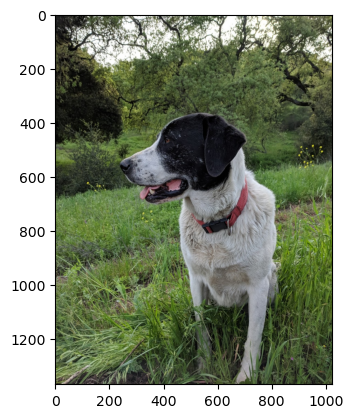

In [3]:
full = cv2.imread("data/sammy.jpg")
full = cv2.cvtColor(full, cv2.COLOR_BGR2RGB)
plt.imshow(full)

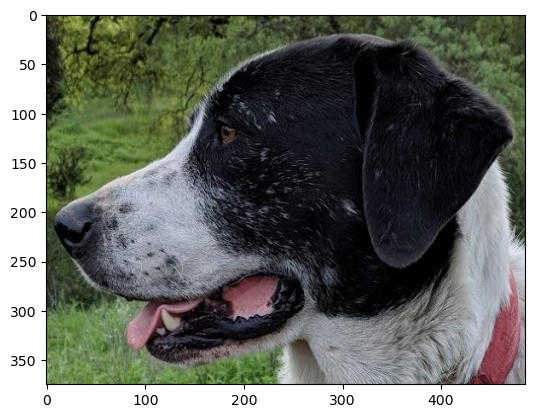

In [5]:
face = cv2.imread("data/sammy_face.jpg")
face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
plt.imshow(face)

In [7]:
# Template matching requires the subset image to be an exact match  in the full image
print(full.shape)
print(face.shape)

height, width, channels = face.shape
print(height)
print(width)
print(channels)

(1367, 1025, 3)
(375, 486, 3)
375
486
3


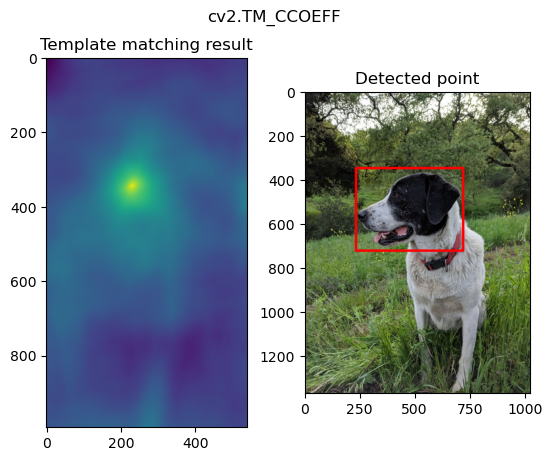

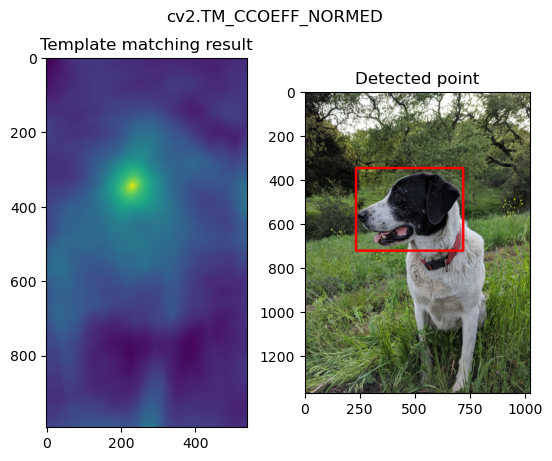

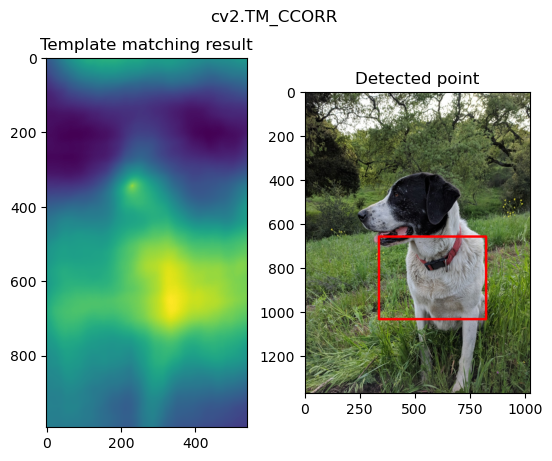

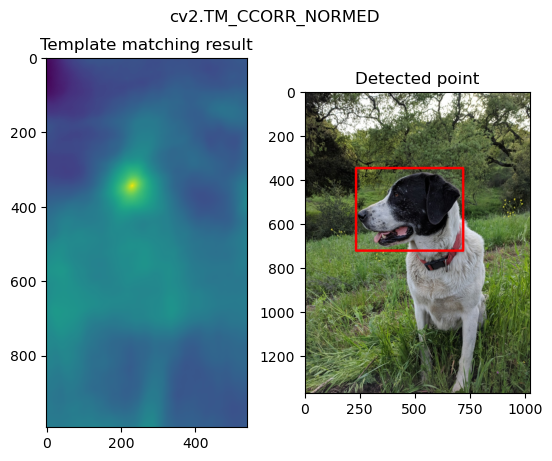

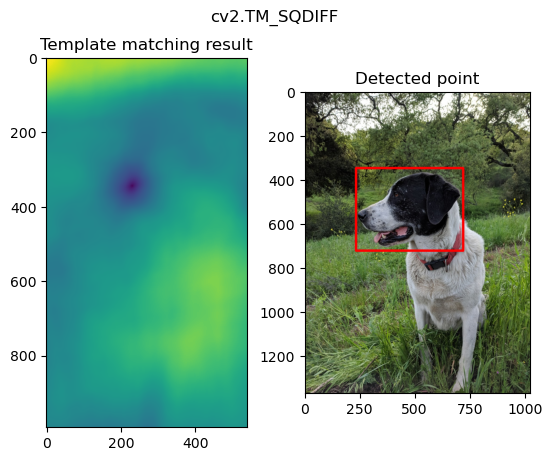

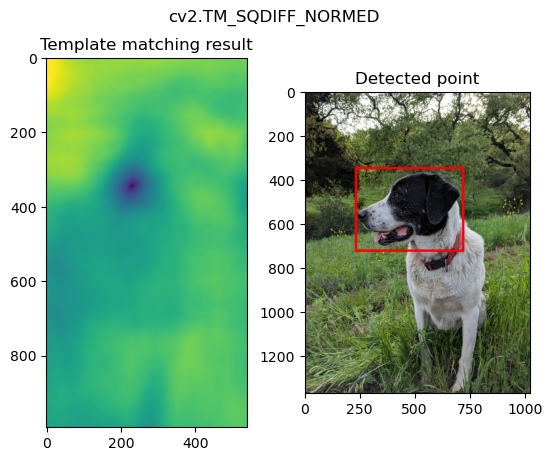

In [14]:
# Including all methods used for comparison
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

for m in methods:
    # Create a copy of the image
    full_copy = full.copy()
    method = eval(m)
    # Template Matching
    res = cv2.matchTemplate(full_copy, face, method)
    # To draw a red rectangle around the matched area
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
    # If the method is TM_SQDIFF or TM_SQDIFF_NORMED, take minimum
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + width, top_left[1] + height)
    cv2.rectangle(full_copy, top_left, bottom_right, 255, 10)

    # Plot the images
    plt.subplot(121)
    plt.imshow(res)
    plt.title("Template matching result")
    plt.subplot(122)
    plt.imshow(full_copy)
    plt.title("Detected point")
    plt.suptitle(m)
    plt.show()
    print("\n")